In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


In [2]:
#spot perfect (and weak) association

# Cramér’s V: Effect size measure for association between two nominal variables (0 = no association, 1 = perfect association).
# Based on chi-square statistic.

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

df = pd.read_parquet('data/votersurvey_cleaned.parquet')   
target = df['presvote16post_2016']                        #use different target variable
features = df.drop(columns=['presvote16post_2016'])

scores = {}
for col in features.columns:
    try:
        scores[col] = cramers_v(features[col].astype(str), target.astype(str))
    except:
        scores[col] = 0

ranked = pd.Series(scores).sort_values(ascending=False)
print(ranked.head(40))  # Top 20 — anything > 0.7 is suspicious

# Nothing seems to associate to well, exept izip_2016 of course
# But it's interesting that the fealing thermometer's "seem" to be good predictors (let's see...)


/tmp/ipykernel_199/851130710.py:11: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r, k) - 1)))
/tmp/ipykernel_199/851130710.py:11: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r, k) - 1)))


izip_2016                      0.934478
Clinton_Cruz_2016              0.923726
fav_trump_2016                 0.918273
fav_hrc_2016                   0.913824
fav_obama_2016                 0.910290
obamaapp_2016                  0.899948
Sanders_Trump_2016             0.898518
Clinton_Rubio_2016             0.890413
healthreformbill_2016          0.865410
pid7_2016                      0.831557
Sanders_Rubio_2016             0.819683
policies_favor_2016            0.749548
fav_sanders_2016               0.747739
ft_blm_2016                    0.746541
univhealthcov_2016             0.740341
immi_muslim_2016               0.740076
envwarm_2016                   0.722531
pp_primary16_2016              0.718641
imiss_l_2016                   0.718520
fav_cruz_2016                  0.712882
govt_reg_2016                  0.712532
pid3_2016                      0.712414
ideo5_2016                     0.706501
wealth_2016                    0.693406
immi_contribution_2016         0.686780


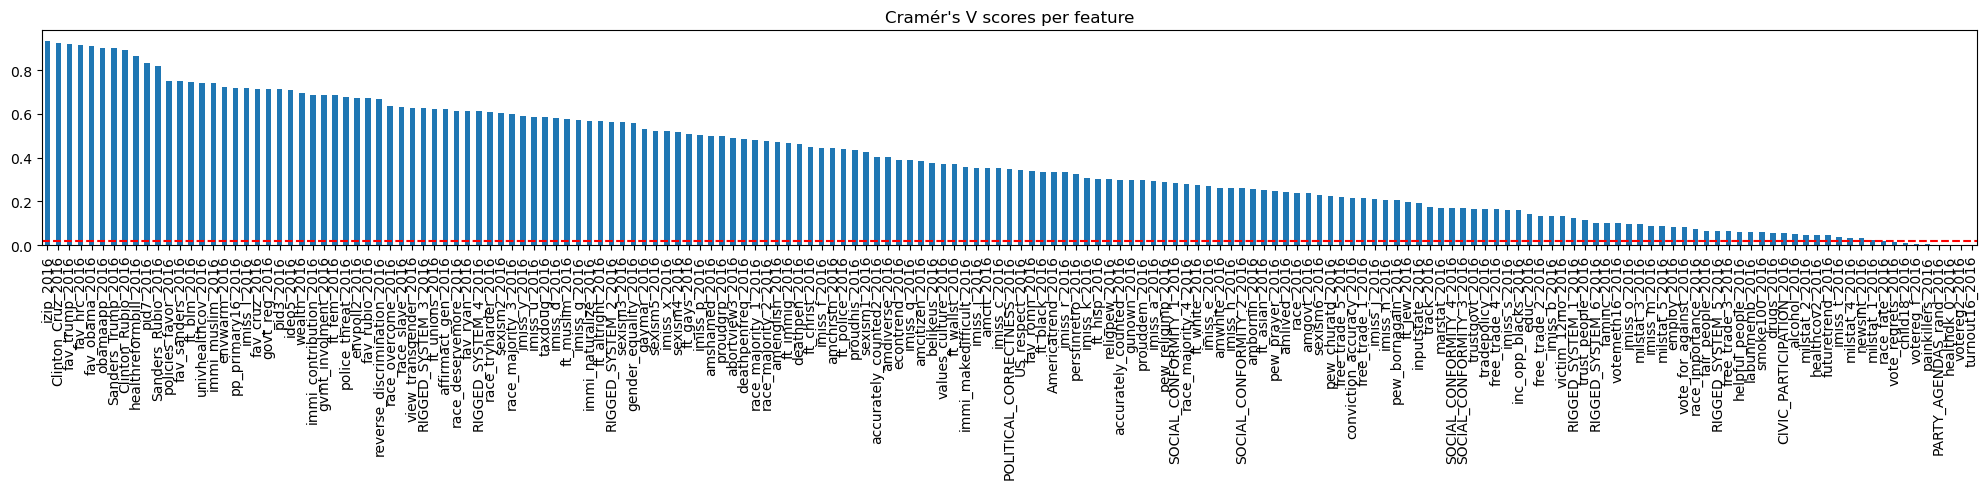

In [3]:
import matplotlib.pyplot as plt

# ellbow method: to decide the threshold to drop columns

ranked.plot(kind='bar', figsize=(20, 5))
plt.axhline(y=0.02, color='red', linestyle='--')
plt.title('Cramér\'s V scores per feature')
plt.tight_layout()
plt.show()

# 


In [16]:
# drop leaky (too high) and uninformative (too low)
to_keep = ranked[(ranked <= 0.7) & (ranked > 0.1)].index.tolist()
to_keep.append('presvote16post_2016')

df_vote = df[df['presvote16post_2016'].isin(['Hillary Clinton', 'Donald Trump'])].copy()
df_vote_selected = df_vote[[c for c in to_keep if c in df_vote.columns]]

print(df_vote_selected.shape)
print("Features kept:", df_vote_selected.shape[1] - 1)

(2861, 120)
Features kept: 119


In [13]:
#drop known artifact

# find constant columns (only 1 answer type)
for col in df.columns:
    if df[col].nunique() <= 1:
        print(col)

        
#drop the corresponding columns + the zipcode
#df = df.drop(columns=['izip_2016', "votereg2_2016","turnout16_2016"])
#not necessary anymore ... diese wurden vom Cramer's V gespottet

In [14]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [15]:
# try out

import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import lightgbm as lgb

# ── Prepare data ────────────────────────────────────────────────────


df_vote = df[df['presvote16post_2016'].isin(['Hillary Clinton', 'Donald Trump'])]

y = (df_vote['presvote16post_2016'] == 'Donald Trump').astype(int)          #Trump = 1, Clinton = 0
X = df_vote.drop(columns=['PARTY_AGENDAS_rand_2016', 'presvote16post_2016'])

# ── Encode categoricals → numbers (both models need this) ───────────
cat_cols   = X.select_dtypes(include='category').columns.tolist()
float_cols = X.select_dtypes(include='float64').columns.tolist()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

# ── Train/test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Logistic Regression (needs scaling) ─────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

print("── Logistic Regression ──")
print(classification_report(y_test, lr.predict(X_test_sc)))
print("ROC-AUC:", round(roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]), 4))

# ── LightGBM (no scaling needed) ────────────────────────────────────
lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                           max_depth=6, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(50, verbose=False)])

print("\n── LightGBM ──")
print(classification_report(y_test, lgbm.predict(X_test)))
print("ROC-AUC:", round(roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1]), 4))

── Logistic Regression ──
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       341
           1       0.95      0.94      0.95       232

    accuracy                           0.96       573
   macro avg       0.96      0.95      0.95       573
weighted avg       0.96      0.96      0.96       573

ROC-AUC: 0.9917

── LightGBM ──
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       341
           1       0.98      0.98      0.98       232

    accuracy                           0.99       573
   macro avg       0.99      0.99      0.99       573
weighted avg       0.99      0.99      0.99       573

ROC-AUC: 0.9984


In [18]:
# try out

import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import lightgbm as lgb

# ── Prepare data ────────────────────────────────────────────────────
df_vote = df_vote_selected[df_vote_selected['presvote16post_2016'].isin(['Hillary Clinton', 'Donald Trump'])]

y = (df_vote['presvote16post_2016'] == 'Donald Trump').astype(int)
X = df_vote.drop(columns=['presvote16post_2016'])

# ── Encode categoricals → numbers (both models need this) ───────────
cat_cols   = X.select_dtypes(include='category').columns.tolist()
float_cols = X.select_dtypes(include='float64').columns.tolist()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

# ── Train/test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Logistic Regression (needs scaling) ─────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

print("── Logistic Regression ──")
print(classification_report(y_test, lr.predict(X_test_sc)))
print("ROC-AUC:", round(roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]), 4))

# ── LightGBM (no scaling needed) ────────────────────────────────────
lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                           max_depth=6, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(50, verbose=False)])

print("\n── LightGBM ──")
print(classification_report(y_test, lgbm.predict(X_test)))
print("ROC-AUC:", round(roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1]), 4))

── Logistic Regression ──
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       341
           1       0.91      0.88      0.89       232

    accuracy                           0.92       573
   macro avg       0.92      0.91      0.91       573
weighted avg       0.92      0.92      0.92       573

ROC-AUC: 0.9771

── LightGBM ──
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       341
           1       0.93      0.89      0.91       232

    accuracy                           0.93       573
   macro avg       0.93      0.92      0.93       573
weighted avg       0.93      0.93      0.93       573

ROC-AUC: 0.9867


In [19]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]
Note: you may need to restart the kernel to use updated packages.


/opt/conda/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


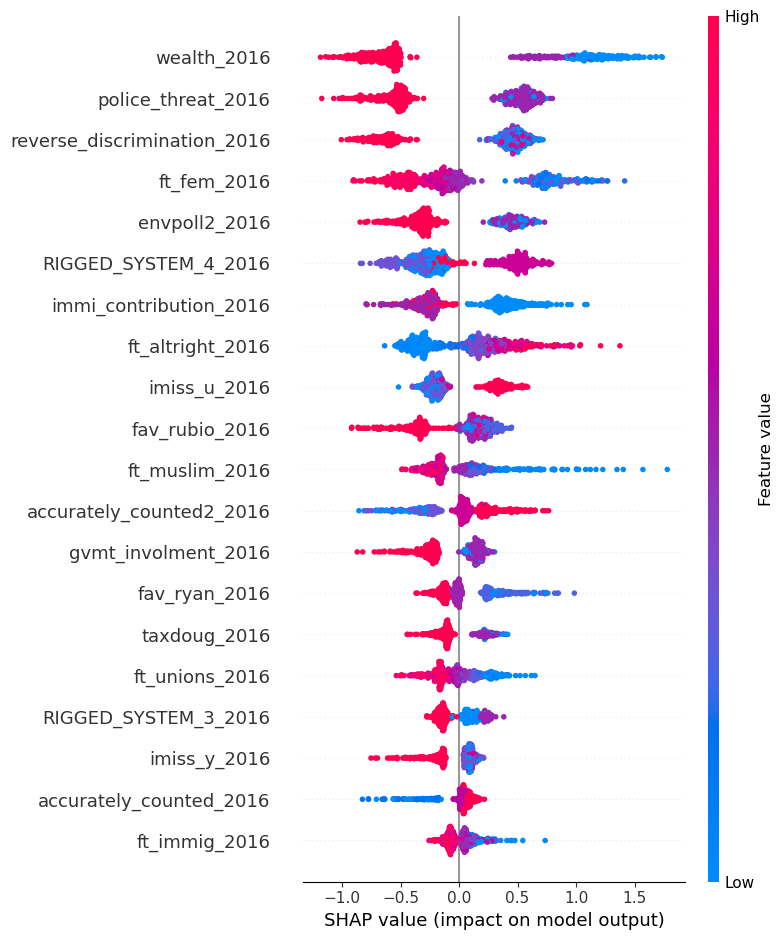

In [28]:
import shap
#SHAP interpretation info:
# each dot a person
# color= actual value (high value infeeling thermometer: red, low value: blue)
# --> less important for the ordinary data, but nice info for feeling thermometer
# Dot at 0: this feature has no impact on persons prediction
# right of 0: impact on trump choice // left of 0: impact on Clinton choice
# As I understand it: If data is well splitted: right-left, this feature seems to be more important

# compute SHAP values on the test set
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

# beeswarm plot — shows direction and magnitude per feature
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.show()
#plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight', facecolor='white')
#plt.close()